In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.onekg as og

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [3]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 681512 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 85106
protein: 2142


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


In [ ]:
vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[vep_files['model_location']=="esm2_t33_650M_UR50D"]
    )

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 57984 masked-marginals parquet files


Reading files:   0%|          | 0/57984 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 7.31GB/s]


VEP dataframe shape: (2028077, 72)


In [ ]:
haplotypes = hs.get_haplotypes(cache_only=True,
                                tx_ids=vep_df['ENST'].unique()
                                ) 

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/1450 [00:00<?, ?it/s]

In [ ]:
haps_df= hs.get_haplotype_names(haplotypes=haplotypes, 
                                as_df=True, 
                                split_variants=True) 

Getting haplotype names:   0%|          | 0/1450 [00:00<?, ?it/s]

In [ ]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes, 
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=True)
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/1450 [00:00<?, ?it/s]

Processing sample to haplotype name maps:   0%|          | 0/1450 [00:00<?, ?it/s]

/home/schilder/projects/VEP_protein/src/haplosaurus.py:2257: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<NA>' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  haps_to_ref.loc[:,["Gender"]] = pd.NA


,sample,ENST_haplosaurus,haplotype,Gender,Population,Super Population
0,REF,ENST00000001146,ENSP00000001146:REF,<NA>,REF,REF
5008,REF,ENST00000003084,ENSP00000003084:REF,<NA>,REF,REF
10016,REF,ENST00000005257,ENSP00000005257:REF,<NA>,REF,REF
15024,REF,ENST00000029410,ENSP00000029410:REF,<NA>,REF,REF
20032,REF,ENST00000037502,ENSP00000037502:REF,<NA>,REF,REF


array([[<Axes: title={'center': 'variant'}>]], dtype=object)

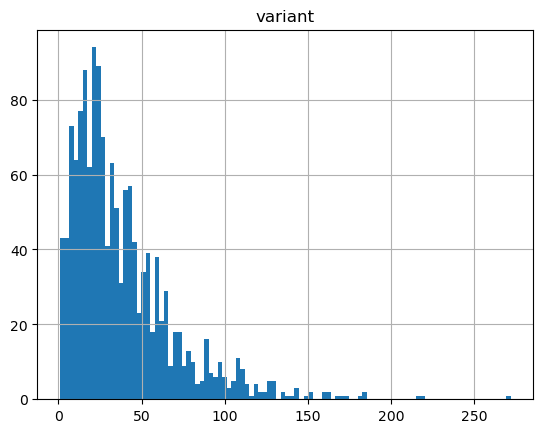

In [ ]:
haps_df.groupby(["ENST"]).agg({"variant":"nunique"}).sort_values("variant", ascending=False).hist(bins=100)

## WT variant attribution analysis

Identify the WT variants (observed naturally occurring  in the  biobank cohort). 
Then find how frequency those variants are (inferred by extracting them from the haplotype names after expanding the data from the unique haplotype --> individual level).

Using side-by-side heatmaps we can find superpopulation x WT variant clusters that are frequent in a given superpopulation and/or high mean VEP (across all injected variants). 

In this way, we can identify (superpopulation-specific) WT variants that confer sensitivity to ClinVar variants in general.  

We could also recompute this plot to show only average VEP for a specific ClinVar variant of interest to see which WT variants confer sensitivity to it.

Getting haplotype frequencies:   0%|          | 0/1450 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    14374
1000GENOMES:phase_3:EAS     9624
1000GENOMES:phase_3:SAS     8993
1000GENOMES:phase_3:EUR     6757
1000GENOMES:phase_3:AMR     4774
Name: count, dtype: int64

Percentage of population-specific haplotypes: 76.60%


/home/schilder/projects/VEP_protein/src/vep_analysis.py:2638: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  var_freqs_agg = var_freqs_agg.fillna(fillna)


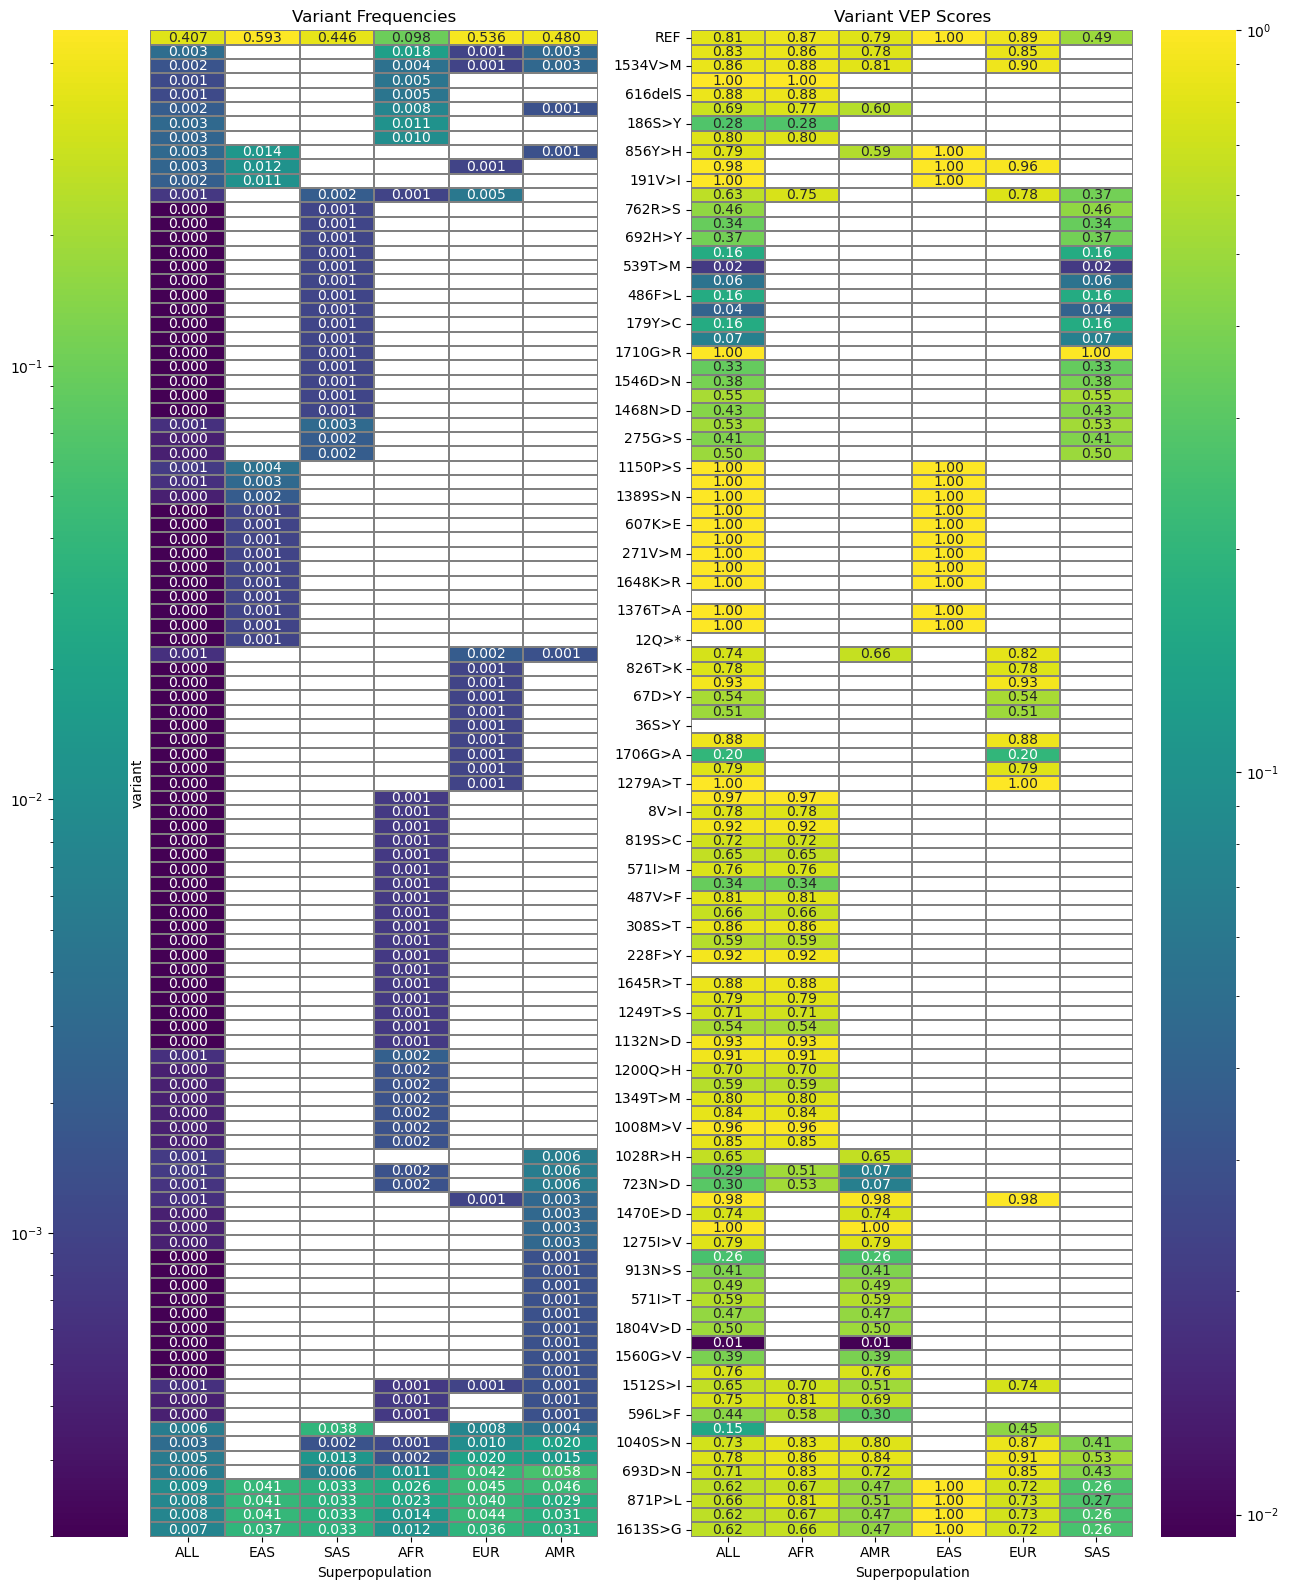

In [ ]:
vep_prot, var_vep_agg, var_freqs_agg, fig = va.get_wt_variant_vep_scores(vep_df=vep_df, 
                                                               haps_df=haps_df,
                                                               haplotypes=haplotypes, 
                                                               haps_to_samples=haps_to_samples,
                                                               protein='NP_009225.1'
                                                               )

### Dotplot

Same information as the dual heatmaps above, but condense into a single dotplot where the size is the variant frequency and the color is the mean VEP score.

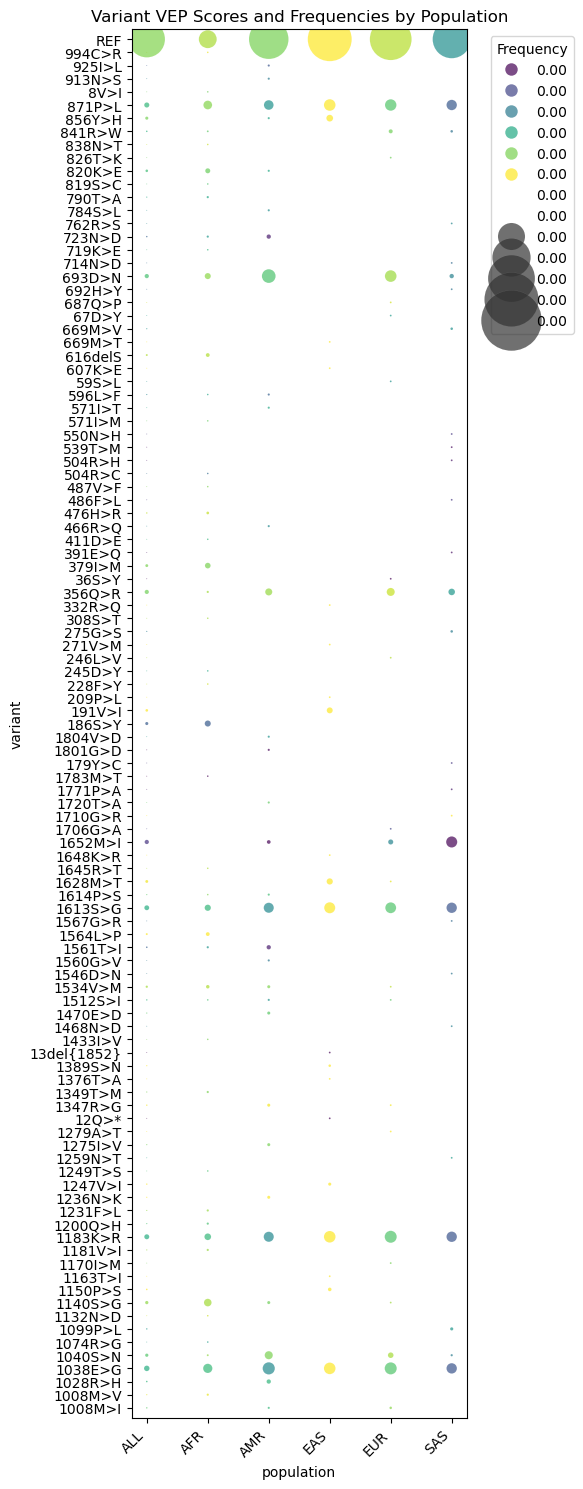

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create figure and axis
plt.figure(figsize=(6, 15))

# Melt the dataframes
vep_melted = var_vep_agg.reset_index().melt(id_vars='variant', 
                                           var_name='population',
                                           value_name='vep_score')

freq_melted = var_freqs_agg.reset_index().melt(id_vars='variant',
                                             var_name='population',
                                             value_name='frequency')

# Merge the melted dataframes
plot_data = vep_melted.merge(freq_melted, on=['variant', 'population'])

# Create scatter plot using seaborn
scatter = sns.scatterplot(data=plot_data,
                         x='population',
                         y='variant',
                         hue='vep_score',
                         size='frequency',
                         sizes=(0, 1000),  # Scale sizes for better visibility
                         palette='viridis',
                         alpha=0.7)

# Get handles and labels for size legend
handles, labels = scatter.get_legend_handles_labels()
# Remove the hue legend
scatter.legend_.remove()

# Create custom size legend with meaningful labels
size_legend = plt.legend(handles[1:], 
                        [f'{freq:.2f}' for freq in sorted(plot_data['frequency'].unique())],  # Sort frequencies
                        title='Frequency',
                        bbox_to_anchor=(1.05, 1),
                        loc='upper left',
                        markerscale=1.5)  # Make legend markers larger

# Set labels and ticks
plt.xticks(rotation=45, ha='right')

# Set y-axis limits to remove extra whitespace
plt.ylim(-0.75, len(plot_data['variant'].unique()) - 0.25)

# Add title and adjust layout
plt.title('Variant VEP Scores and Frequencies by Population')
plt.tight_layout()

# Show plot
plt.show()

## Pairwise Variant Sensitization Analysis

Compare mean VEP across WT variants for each injected ClinVar variant.

In [ ]:

mutant_pos = vep_prot[["mutant","Protein_position"]].drop_duplicates()
# variant_pos = vep_prot[["variant","Protein_position"]].drop_duplicates()
variant_pos

,variant,Protein_position
10485,1710G>R,18
10453,1710G>R,47
10482,1710G>R,22
10481,1710G>R,24
10477,1710G>R,27
...,...,...
6353,13del{1852},37
6380,12Q>*,7
6381,13del{1852},7
6382,12Q>*,6


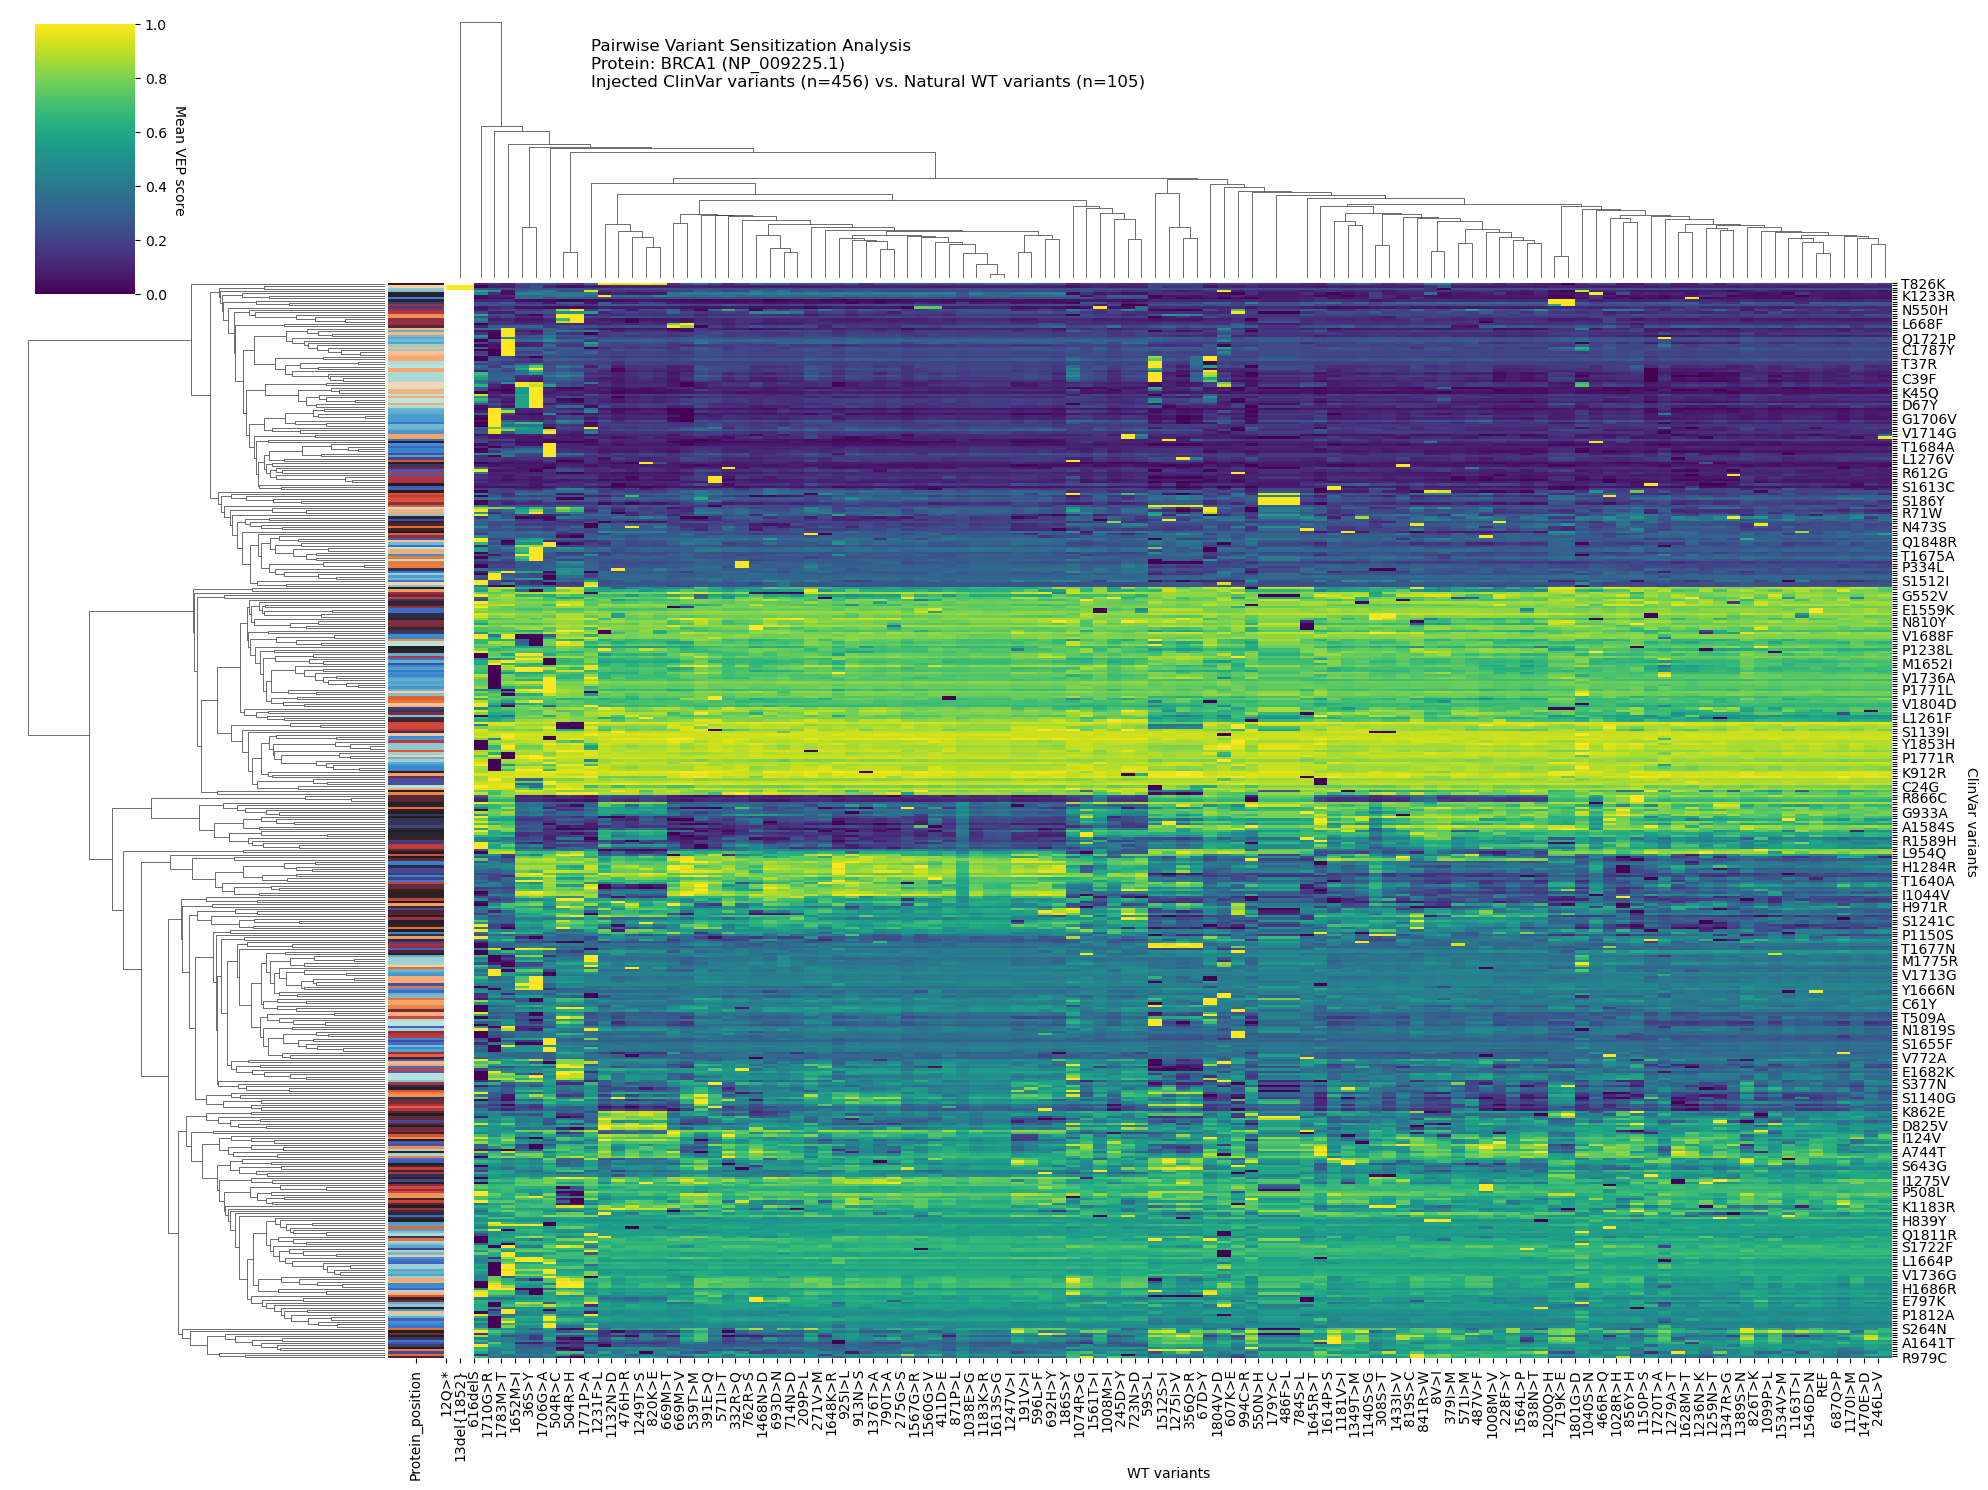

In [ ]:
# Fill NaN values with 0
# First create the pivot table
clinvar_vs_wt = vep_prot.pivot_table(index="mutant", columns="variant", values="VEP", aggfunc="mean")

mutant_pos = vep_prot[["mutant","Protein_position"]].drop_duplicates()
variant_pos = vep_prot[["variant","Protein_position"]].drop_duplicates()



# Min-max normalize each row
clinvar_vs_wt = clinvar_vs_wt.sub(clinvar_vs_wt.min(axis=1), axis=0)
clinvar_vs_wt = clinvar_vs_wt.div(clinvar_vs_wt.max(axis=1), axis=0)

cmap = utils.make_palette(mutant_pos["Protein_position"].unique(), palette="icefire")

# Create a mask for the original NaN values
mask = clinvar_vs_wt.isna()

# clinvar_vs_wt = np.log1p(clinvar_vs_wt)

# Create clustermap with masked values
g = sns.clustermap(clinvar_vs_wt.fillna(0), 
               figsize=(20,15),
               mask=mask,
               row_colors=mutant_pos.set_index("mutant").reindex(clinvar_vs_wt.index)["Protein_position"].map(cmap),
               cmap='viridis')

# Get the number of labels to show (80)
n_labels_x = 200
n_labels_y = 80

# Get the reordered indices after clustering
x_order = g.dendrogram_col.reordered_ind
y_order = g.dendrogram_row.reordered_ind

# Calculate evenly spaced indices for labels
x_indices = np.linspace(0, len(x_order)-1, n_labels_x, dtype=int)
y_indices = np.linspace(0, len(y_order)-1, n_labels_y, dtype=int)

# Set x-axis ticks and labels
g.ax_heatmap.set_xticks(range(len(clinvar_vs_wt.columns)))
g.ax_heatmap.set_xticklabels([clinvar_vs_wt.columns[x_order[i]] if i in x_indices else '' for i in range(len(x_order))])

# Set y-axis ticks and labels
g.ax_heatmap.set_yticks(range(len(clinvar_vs_wt.index)))
g.ax_heatmap.set_yticklabels([clinvar_vs_wt.index[y_order[i]] if i in y_indices else '' for i in range(len(y_order))])

g.ax_heatmap.collections[0].colorbar.set_label("Mean VEP score", rotation=270, va="bottom")
g.ax_heatmap.set_xlabel("WT variants")
g.ax_heatmap.set_ylabel("ClinVar variants", rotation=270, va="bottom")
g.ax_heatmap.set_title(f"Pairwise Variant Sensitization Analysis\nProtein: {vep_prot["GENEINFO"].unique()[0].split(':')[0]} ({vep_prot['protein'].unique()[0]})\nInjected ClinVar variants (n={clinvar_vs_wt.shape[0]}) vs. Natural WT variants (n={clinvar_vs_wt.shape[1]})",
                       ha="left", x=0.1, y=1.175)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import gridspec
from scipy import stats
from scipy.cluster import hierarchy

# Get data for NP_009225.1 and merge with haplotypes
protein_data = vep_df.loc[vep_df['protein'] == 'NP_009225.1'].merge(haps_to_samples, on=["haplotype"], how="left")
print(protein_data.shape)

gene_list = list(set([x.split(':')[0] for x in protein_data["GENEINFO"].unique()]))

# Create pivot table for heatmap and transpose it
heatmap_data = protein_data.pivot_table(
    index='sample',
    columns='mutant',
    values='VEP',
    aggfunc="mean"
)
# Min-max normalize the heatmap data
heatmap_data = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
# Log transform the data first
heatmap_data = np.log1p(heatmap_data)

# Get super population info for each sample and create a numeric mapping
pop_data = haps_to_samples[['sample', 'Super Population']].drop_duplicates()
pop_data = pop_data.set_index('sample')

# Reindex pop_data to match the row order of heatmap_data
pop_data = pop_data.reindex(heatmap_data.index)

# Create numeric mapping for populations
pop_mapping = {pop: i for i, pop in enumerate(pop_data['Super Population'].unique())}
pop_data['Superpop'] = pop_data['Super Population'].map(pop_mapping)

gender_data = haps_to_samples[['sample', 'Gender']].drop_duplicates()
gender_data = gender_data.set_index('sample')

gender_data = gender_data.reindex(heatmap_data.index)

gender_mapping = {gender: i for i, gender in enumerate(gender_data['Gender'].unique())}
gender_data['Gender'] = gender_data['Gender'].map(gender_mapping)


(2284104, 77)


Number of col clusters: 73


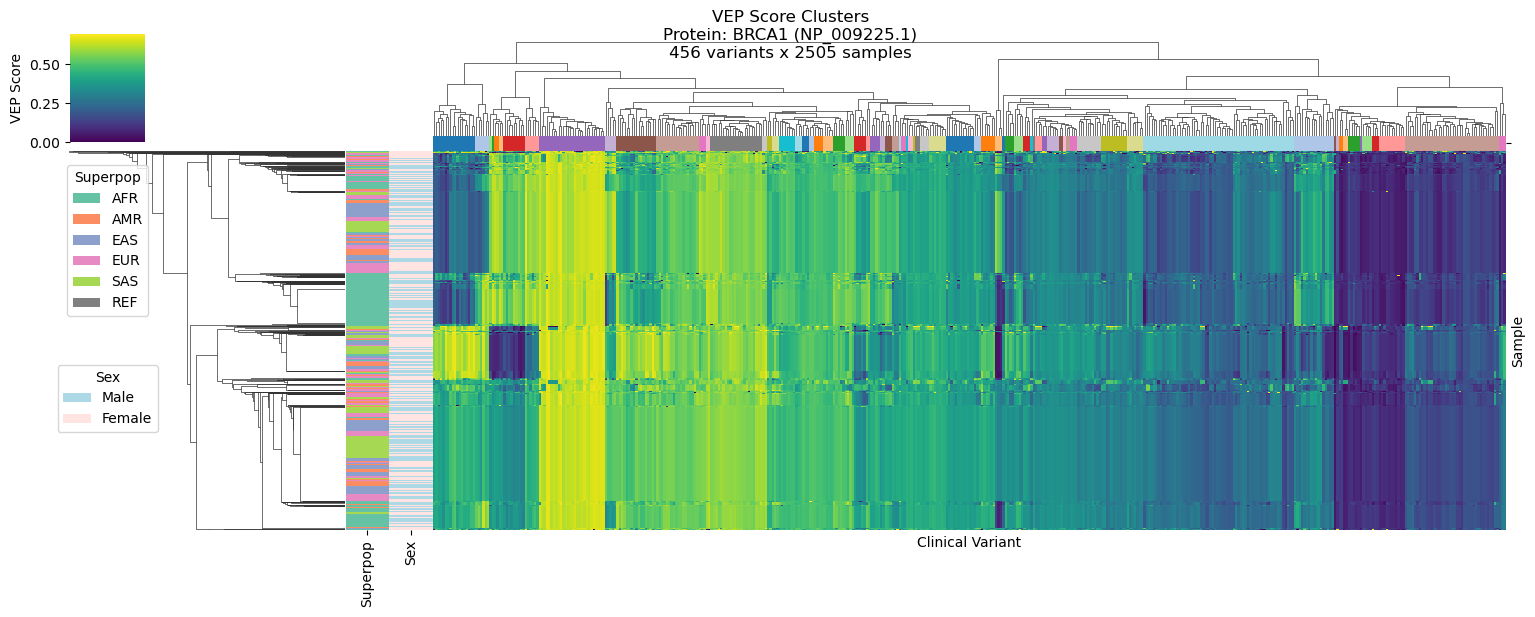

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Main clustermap
# Create row colors dataframe with both Super Population and Gender
gender_palette = {0: 'lightblue', 1: 'mistyrose'}
row_colors = pd.DataFrame({
    'Superpop': pop_data['Super Population'].map(utils.get_superpop_palette()),
    'Sex': gender_data['Gender'].map(gender_palette)  # Map gender values to colors
})

# Create clustermap but don't display it
g1 = sns.clustermap(heatmap_data,
                    figsize=(15,6),
                   cmap='viridis',
                   cbar_kws={'label': 'VEP Score', 'location': 'left', 'pad': 0.025},
                   row_colors=row_colors,
                   yticklabels=False,
                   xticklabels=False)
plt.close()  # Close the figure to prevent display

# Get the column linkage
col_linkage = g1.dendrogram_col.linkage

# Use scipy's fcluster to get cluster assignments 
t = 1.15
col_clusters = fcluster(col_linkage, t=t, criterion='inconsistent')
n_clusters = len(np.unique(col_clusters))
print(f"Number of col clusters: {n_clusters}")

# Create variant to cluster mapping
variant_to_cluster = {}
for variant_id, cluster_id in zip(heatmap_data.columns, col_clusters):
    variant_to_cluster[variant_id] = cluster_id

# Create a color palette for the clusters
cluster_colors = sns.color_palette('tab20', n_colors=n_clusters)
col_colors = pd.Series([cluster_colors[i-1] for i in col_clusters], index=heatmap_data.columns)

# Create final clustermap with both row and column colors
g1 = sns.clustermap(heatmap_data,
                    figsize=(15,6),
                   cmap='viridis',
                   cbar_kws={'label': 'VEP Score', 'location': 'left', 'pad': 0.025},
                   row_colors=row_colors,
                   col_colors=col_colors,
                   yticklabels=False,
                   xticklabels=False)

# Add title centered on the heatmap
g1.fig.suptitle(f'VEP Score Clusters\nProtein: {gene_list[0] if len(gene_list) == 1 else len(gene_list)} ({protein_data["protein"].unique()[0]})\n{heatmap_data.shape[1]} variants x {heatmap_data.shape[0]} samples',
                x=0.5, y=1.02, ha='center')

# Add x-axis label
g1.ax_heatmap.set_xlabel('Clinical Variant')

# Add y-axis label and rotate it horizontally
g1.ax_heatmap.set_ylabel('Sample')
g1.ax_heatmap.yaxis.set_label_position('right')
g1.ax_heatmap.yaxis.tick_right()

# Add legends for row colors
# Super Population legend
palette = utils.get_superpop_palette()
handles = [plt.Rectangle((0,0),1,1, facecolor=color) for color in palette.values()]
labels = list(palette.keys())
superpop_legend = plt.legend(handles, labels,
          title='Superpop', 
          bbox_to_anchor=(0.5, -0.15),
          loc='upper center',
          ncol=1)

# Add the first legend to the plot
plt.gca().add_artist(superpop_legend)

# Gender legend
gender_handles = [plt.Rectangle((0,0),1,1, facecolor=color) for color in gender_palette.values()]
gender_labels = ['Male', 'Female']
plt.legend(gender_handles, gender_labels,
          title='Sex',
          bbox_to_anchor=(0.5, -2),
          loc='upper center',
          ncol=1)

In [ ]:
rm_cols = ["sample","haplotype","is_ref","Super Population","Population","Gender","VEP"]
mutant_df = protein_data.drop(columns=rm_cols).drop_duplicates()
# mutant_df = mutant_df.groupby([col for col in mutant_df.columns if col != 'VEP']).agg({"VEP":"mean"}).reset_index()
mutant_df["mutant_cluster"] = mutant_df["mutant"].map(variant_to_cluster)
# Count unique variants per cluster
cluster_variant_counts = mutant_df.groupby('mutant_cluster')['mutant'].nunique().reset_index()
cluster_variant_counts.columns = ['mutant_cluster', 'mutants_per_cluster']

# Merge with original dataframe
mutant_df = mutant_df.merge(cluster_variant_counts, on='mutant_cluster', how='left')

mutant_df


,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,scoring_strategy,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,ENST_haplosaurus,mutant_cluster,mutants_per_cluster
0,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,H1860Q,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045690,1748423,G,T,.,PASS,1748423,17:43045690,T,672,NM_007294.4,Transcript,missense_variant,5693,5580,1860,H/Q,caC/caA,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5580C>A,NP_009225.1:p.His1860Gln,-,NaN,NaN,1806671,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.43045690G>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632517,NaN,5,likely_benign,ENST00000357654,2,6
1,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1859R,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045694,55634,G,C,.,PASS,55634,17:43045694,C,672,NM_007294.4,Transcript,missense_variant,5689,5576,1859,P/R,cCc/cGc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5576C>G,NP_009225.1:p.Pro1859Arg,-,NaN,0.00002,70301,"MedGen:CN517202|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.43045694G>C,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357322,NaN,BRCA1-HCI:BRCA1_00098|ClinGen:CA003729,NaN,NaN,NaN,NaN,NaN,-0.490676,NaN,5,benign,ENST00000357654,57,11
2,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,I1858L,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045698,183951,T,G,.,PASS,183951,17:43045698,G,672,NM_007294.4,Transcript,missense_variant,5685,5572,1858,I/L,Atc/Ctc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_007294.4:c.5572A>C,NP_009225.1:p.Ile1858Leu,-,NaN,0.00006,184864,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_sp...,NC_000017.11:g.43045698T>G,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,765656957,NaN,BRCA1-HCI:BRCA1_00097|ClinGen:CA003726,NaN,NaN,NaN,NaN,NaN,0.791910,NaN,5,benign,ENST00000357654,60,64
3,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1856S,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045704,55632,G,A,.,PASS,55632,17:43045704,A,672,NM_007294.4,Transcript,missense_variant,5679,5566,1856,P/S,Ccc/Tcc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5566C>T,NP_009225.1:p.Pro1856Ser,-,NaN,0.00002,70299,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Heredi...,NC_000017.11:g.43045704G>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357274,NaN,ClinGen:CA003722,NaN,N

In [ ]:
# https://biopython.org/docs/1.75/api/Bio.SeqIO.UniprotIO.html?highlight=uniprot#module-Bio.SeqIO.UniprotIO
import requests
from Bio import SeqIO
from io import StringIO

response = requests.get("https://rest.uniprot.org/uniprotkb/P38398.xml")
if response.status_code == 200:
    records = SeqIO.parse(StringIO(response.text), "uniprot-xml")
    for record in records:
        print(record.id)
        print(record.name)
        print(record.seq)
        print(record.description)
        # ... other attributes like features, dbxrefs, etc.
else:
    print(f"Failed to fetch data. Status code: {response.status_code}")


P38398
MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQKKGPSQCPLCKNDITKRSLQESTRFSQLVEELLKIICAFQLDTGLEYANSYNFAKKENNSPEHLKDEVSIIQSMGYRNRAKRLLQSEPENPSLQETSLSVQLSNLGTVRTLRTKQRIQPQKTSVYIELGSDSSEDTVNKATYCSVGDQELLQITPQGTRDEISLDSAKKAACEFSETDVTNTEHHQPSNNDLNTTEKRAAERHPEKYQGSSVSNLHVEPCGTNTHASSLQHENSSLLLTKDRMNVEKAEFCNKSKQPGLARSQHNRWAGSKETCNDRRTPSTEKKVDLNADPLCERKEWNKQKLPCSENPRDTEDVPWITLNSSIQKVNEWFSRSDELLGSDDSHDGESESNAKVADVLDVLNEVDEYSGSSEKIDLLASDPHEALICKSERVHSKSVESNIEDKIFGKTYRKKASLPNLSHVTENLIIGAFVTEPQIIQERPLTNKLKRKRRPTSGLHPEDFIKKADLAVQKTPEMINQGTNQTEQNGQVMNITNSGHENKTKGDSIQNEKNPNPIESLEKESAFKTKAEPISSSISNMELELNIHNSKAPKKNRLRRKSSTRHIHALELVVSRNLSPPNCTELQIDSCSSSEEIKKKKYNQMPVRHSRNLQLMEGKEPATGAKKSNKPNEQTSKRHDSDTFPELKLTNAPGSFTKCSNTSELKEFVNPSLPREEKEEKLETVKVSNNAEDPKDLMLSGERVLQTERSVESSSISLVPGTDYGTQESISLLEVSTLGKAKTEPNKCVSQCAAFENPKGLIHGCSKDNRNDTEGFKYPLGHEVNHSRETSIEMEESELDAQYLQNTFKVSKRQSFAPFSNPGNAEEECATFSAHSGSLKKQSPKVTFECEQKEENQGKNESNIKPVQTVNITAGFPVVGQKDKPVDNAKCSIKGGSRFCLSSQFRGNETGLITPNKHGLLQNPYRIPPLFPIKSFVKTK

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/SeqIO/UniprotIO.py:65: BiopythonDeprecationWarning: Opening a UniProt XML file in text mode is deprecated, as it may lead to garbled characters. We recommend opening the file in binary mode; parsing UniProt XML files opened in text mode will no longer be supported in a future release of Biopython.
  warnings.warn(


In [ ]:
features_df = []
for feature in record.features:
    fdict = {}
    fdict["id"] = feature.id
    fdict["type"] = feature.type
    fdict["start"] = feature.location.start
    fdict["end"] = feature.location.end 
    fdict.update(feature.qualifiers)
    features_df.append(fdict)

features_df = pd.DataFrame(features_df)
features_df["length"] = features_df["end"] - features_df["start"]

features_df

,id,type,start,end,description,evidence,original,variation,ref,length
0,PRO_0000055830,chain,0,1863,Breast cancer type 1 susceptibility protein,NaN,NaN,NaN,NaN,1863
1,<unknown id>,domain,1641,1736,BRCT 1,2,NaN,NaN,NaN,95
2,<unknown id>,domain,1755,1855,BRCT 2,2,NaN,NaN,NaN,100
3,<unknown id>,zinc finger region,23,65,RING-type,3,NaN,NaN,NaN,42
4,<unknown id>,region of interest,229,270,Disordered,4,NaN,NaN,NaN,41
...,...,...,...,...,...,...,...,...,...,...
308,<unknown id>,strand,1827,1830,NaN,112,NaN,NaN,NaN,3
309,<unknown id>,strand,1831,1834,NaN,113,NaN,NaN,NaN,3
310,<unknown id>,helix,1834,1844,NaN,113,NaN,NaN,NaN,10
311,<unknown id>,helix,1850,1853,NaN,113,NaN,NaN,NaN,3


In [ ]:
# spliceai_cols = [x for x in muts.columns if x.startswith("SpliceAI_pred_D")]

# annot_cols  = [
#     #### CADD ####
#     "CADD_PHRED","CADD_RAW",

#     #### REVEL ####
#     "REVEL",

#     #### MaveDB ####
#    "MaveDB_score_mean", 
#    "MaveDB_score_abs_mean",
# #    "MaveDB_score_min",
# #    "MaveDB_score_max",


#     #### EVE ####
#     "EVE_SCORE",
    
#     #### ClinPred ####
#     "ClinPred",

#     #### RF ####
#     "rf_score",

#     #### AdaScore ####
#     "ada_score",

#     #### MaxEntScan ####
#     'MaxEntScan_diff',
    
#     #### LOEUF ####
#     "LOEUF",
    
#     #### AlphaMissense ####
#     "am_pathogenicity",

#     ### SpliceAI ####
#     *spliceai_cols,
#     #### OpenTargets ####
# #    "OpenTargets_l2g",


#     #### Allele Frequences ####
#     "gnomADe_AF","gnomADg_AF","AF_TGP",
#     "AllOfUs_gvs_all_af", "AllOfUs_gvs_max_af",

#     # "MOTIF_SCORE_CHANGE",

#     #### pHaplo ####
#     # "pHaplo" => "Probability of haploinsufficiency (deletion intolerance) of the affected gene",
#     # "pTriplo" => "Probability of triplosensitivity (duplication intolerance) of the affected gene"
#     "pHaplo",
#     "pTriplo",


#     ### Conservation ####
#     "SIFT_score",
#     "PolyPhen_score",
#     ]


#  # Create heatmap with protein position on x-axis and other features on y-axis
#  plt.figure(figsize=(15, 8))
#  sns.heatmap(cv_annot.loc[cv_annot["SYMBOL"] == "BRCA1" ,["Protein_position"]+[x for x in annot_cols if x in cv_annot.columns]].set_index("Protein_position").T
#             cmap='RdBu_r',
#             center=0,
#             annot=True,
#             fmt='.2f',
#             square=True)
#  plt.title('Feature Values by Protein Position')
#  plt.xlabel('Protein Position')
#  plt.ylabel('Features')
#  plt.tight_layout()

Cluster 68 has 11 unique variants


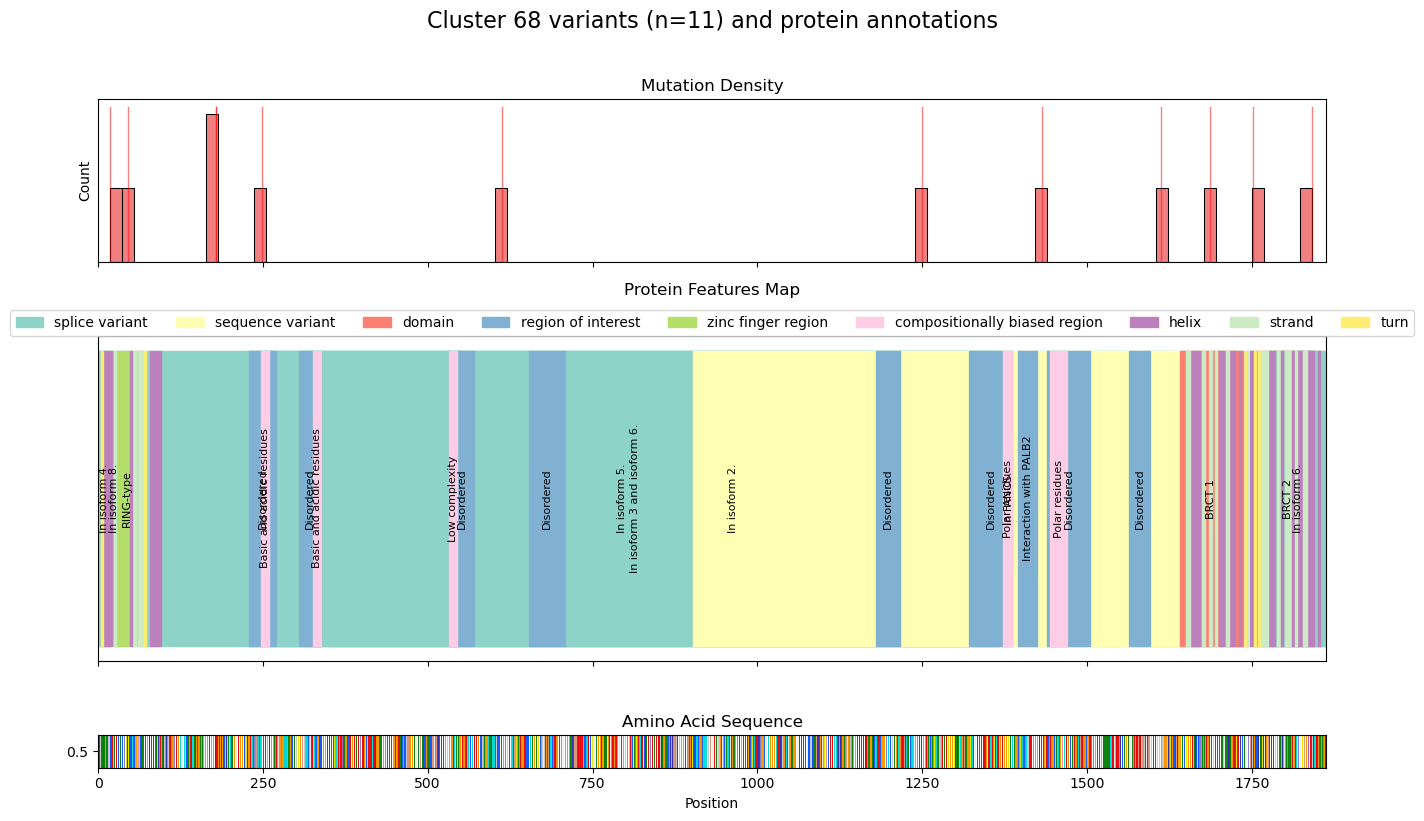

In [ ]:
include_types = None
min_length = 2
exclude_types = ["chain",]
max_len = features_df.loc[features_df["type"] == "chain", "end"][0]


mutant_df = mutant_df.sort_values('mutants_per_cluster', ascending=False)
cluster_id = mutant_df["mutant_cluster"].unique()[9]
muts = mutant_df.loc[mutant_df["mutant_cluster"] == cluster_id]
# Merge annotation data from EnsemblVEP
# muts = muts.merge(cv_annot, on="mutant", how="left")



print(f"Cluster {cluster_id} has {muts['mutants_per_cluster'].iloc[0]} unique variants")

seq = str(record.seq)

plot_df = features_df.copy()
plot_df.sort_values("length",ascending=False, inplace=True)

if include_types is not None:
    plot_df = plot_df[plot_df["type"].str.contains("|".join(include_types))]

if min_length is not None:
    plot_df = plot_df[plot_df["length"] >= min_length]

if exclude_types is not None:
    plot_df = plot_df[~plot_df["type"].str.contains("|".join(exclude_types))]

# Create figure with three subplots
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(15, 8), height_ratios=[0.5, 1, 0.1], sharex=True)

# Add overall title
fig.suptitle(f'Cluster {cluster_id} variants (n={muts["mutants_per_cluster"].iloc[0]}) and protein annotations', fontsize=16, y=1.02)

# Plot mutations and KDE on top subplot
sns.histplot(data=muts, 
             x='Protein_position', ax=ax0, fill=True, alpha=0.3, bins=100, fc='lightcoral')
y_max = ax0.get_ylim()[1]  # Get the maximum y value once
for pos in muts['Protein_position']:
    ax0.plot([pos, pos], [0, y_max], color='red', alpha=0.5, linewidth=1)
ax0.set_yticks([])
ax0.set_title('Mutation Density')

# Plot features on middle subplot
colors = plt.cm.Set3(np.linspace(0, 1, len(plot_df['type'].unique())))
type_to_color = dict(zip(plot_df['type'].unique(), colors))
for _, feature in plot_df.iterrows():
    if pd.notna(feature['start']) and pd.notna(feature['end']):
        ax1.fill_between([feature['start'], feature['end']], 
                        [-0.1, -0.1], [0.1, 0.1],
                        color=type_to_color[feature['type']],
                        alpha=1,
                        label=feature['type'] if feature['type'] not in ax1.get_legend_handles_labels()[1] else "")
        
        # Add description label if it exists
        if 'description' in feature and pd.notna(feature['description']):
            mid_point = (feature['start'] + feature['end']) / 2
            ax1.text(mid_point, 0, feature['description'],
                    rotation=90, ha='center', va='center',
                    fontsize=8)

# Define amino acid colors based on properties
aa_colors = {
    'A': '#C8C8C8',  # Alanine - Gray
    'C': '#E6E600',  # Cysteine - Yellow
    'D': '#E60A0A',  # Aspartic acid - Red
    'E': '#E60A0A',  # Glutamic acid - Red
    'F': '#3232AA',  # Phenylalanine - Blue
    'G': '#EBEBEB',  # Glycine - Light gray
    'H': '#8282D2',  # Histidine - Light blue
    'I': '#0F820F',  # Isoleucine - Green
    'K': '#145AFF',  # Lysine - Blue
    'L': '#0F820F',  # Leucine - Green
    'M': '#E6E600',  # Methionine - Yellow
    'N': '#00DCDC',  # Asparagine - Cyan
    'P': '#DC9682',  # Proline - Pink
    'Q': '#00DCDC',  # Glutamine - Cyan
    'R': '#145AFF',  # Arginine - Blue
    'S': '#FA9600',  # Serine - Orange
    'T': '#FA9600',  # Threonine - Orange
    'V': '#0F820F',  # Valine - Green
    'W': '#B45AB4',  # Tryptophan - Purple
    'Y': '#3232AA'   # Tyrosine - Blue
}

# Plot amino acids on bottom subplot
if seq:
    for i, aa in enumerate(seq):
        ax2.add_patch(plt.Rectangle((i-0.4, 0), 0.8, 1, 
                                  facecolor=aa_colors.get(aa, '#FFFFFF'),
                                  linewidth=0.1))
    ax2.set_ylim(0, 1)
    ax2.set_yticks([0.5])
    ax2.set_title('Amino Acid Sequence', y=1)
else:
    print("No sequence found")
    ax2.plot([0, max_len], [0.5, 0.5], 'k-', alpha=0.5, linewidth=5, label='Sequence')

# Configure plot appearance
ax1.set_title('Protein Features Map', y=1.1)
ax1.set_yticks([])
ax1.legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', ncol=10)
ax1.set_xlim(0, max_len)

ax2.set_xlabel('Position')
ax2.set_xlim(0, max_len)

plt.tight_layout()

In [1]:
import pyranges as pr

# Convert mutations to pyranges format
mut_ranges = pr.PyRanges(
    chromosomes=["chr1"] * len(muts),
    starts=muts["Protein_position"] - 1,  # Convert to 0-based
    ends=muts["Protein_position"],
    strands=["+"] * len(muts),
    names=muts["mutant"]
)

# Convert features to pyranges format
feature_ranges = pr.PyRanges(
    chromosomes=["chr1"] * len(features_df),
    starts=features_df["start"],
    ends=features_df["end"],
    strands=["+"] * len(features_df),
    names=features_df["type"]
)

# Find overlaps between mutations and features
overlaps = mut_ranges.join(feature_ranges)

# Convert back to pandas DataFrame
overlap_df = overlaps.df

# Count overlaps per feature type
feature_counts = overlap_df.groupby("Name_b")["Name_a"].count().reset_index()
feature_counts.columns = ["feature_type", "overlap_count"]

print("\nOverlap counts by feature type:")
print(feature_counts.sort_values("overlap_count", ascending=False))

# Add overlap information to muts DataFrame
muts["overlapping_features"] = muts["mutant"].map(
    overlap_df.groupby("Name_a")["Name_b"].agg(list).to_dict()
)


NameError: name 'muts' is not defined

In [ ]:
features_df["type"].value_counts()

type
sequence variant                 170
modified residue                  30
mutagenesis site                  27
strand                            19
helix                             15
cross-link                        13
region of interest                 9
splice variant                     8
sequence conflict                  8
compositionally biased region      5
turn                               5
domain                             2
zinc finger region                 1
chain                              1
Name: count, dtype: int64